<center><h1><span style="color: green;">THỰC HÀNH BUỔI 11</span></h1></center>

In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


#  MÔ HÌNH TRỘN GAUSSIAN (GAUSSIAN MIXTURE MODEL)

## 1.Thuật toán EM - Xây dựng chương trình từ Numpy

### Ví dụ 1: Dữ liệu 2D nhân tạo

In [ ]:
import numpy as np
from numpy import random
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy.stats import multivariate_normal

class GMM():
    def __init__(self, k, dim, init_mu=None, init_sigma=None, init_pi=None, colors=None):
        '''
        Define a model with known number of clusters and dimensions.
        input:
            - k: Number of Gaussian clusters
            - dim: Dimension
            - init_mu: initial value of mean of clusters (k, dim)
                       (default) random from uniform[-10, 10]
            - init_sigma: initial value of covariance matrix of clusters (k, dim, dim)
                          (default) Identity matrix for each cluster
            - init_pi: initial value of cluster weights (k,)
                       (default) equal value to all cluster i.e. 1/k
            - colors: Color valu for plotting each cluster (k, 3)
                      (default) random from uniform[0, 1]
        '''
        self.k = k
        self.dim = dim
        if(init_mu is None):
            init_mu = random.rand(k, dim)*20 - 10
        self.mu = init_mu
        if(init_sigma is None):
            init_sigma = np.zeros((k, dim, dim))
            for i in range(k):
                init_sigma[i] = np.eye(dim)
        self.sigma = init_sigma
        if(init_pi is None):
            init_pi = np.ones(self.k)/self.k
        self.pi = init_pi
        if(colors is None):
            colors = random.rand(k, 3)
            for i in range(k):
                colors[i, 2] = i/k
        self.colors = colors

    def init_em(self, X):
        '''
        Initialization for EM algorithm.
        input:
            - X: data (batch_size, dim)
        '''
        self.data = X
        self.num_points = X.shape[0]
        self.z = np.zeros((self.num_points, self.k))

    def e_step(self):
        '''
        E-step of EM algorithm.
        '''
        for i in range(self.k):
            self.z[:, i] = self.pi[i] * multivariate_normal.pdf(self.data, mean=self.mu[i], cov=self.sigma[i])
        self.z /= self.z.sum(axis=1, keepdims=True)

    def m_step(self):
        '''
        M-step of EM algorithm.
        '''
        sum_z = self.z.sum(axis=0)
        self.pi = sum_z / self.num_points
        self.mu = np.matmul(self.z.T, self.data)
        self.mu /= sum_z[:, None]
        for i in range(self.k):
            j = np.expand_dims(self.data, axis=1) - self.mu[i]
            s = np.matmul(j.transpose([0, 2, 1]), j)
            self.sigma[i] = np.matmul(s.transpose(1, 2, 0), self.z[:, i] )
            self.sigma[i] /= sum_z[i]

    def log_likelihood(self, X):
        '''
        Compute the log-likelihood of X under current parameters
        input:
            - X: Data (batch_size, dim)
        output:
            - log-likelihood of X: Sum_n Sum_k log(pi_k * N( X_n | mu_k, sigma_k ))
        '''
        ll = []
        for d in X:
            tot = 0
            for i in range(self.k):
                tot += self.pi[i] * multivariate_normal.pdf(d, mean=self.mu[i], cov=self.sigma[i])
            ll.append(np.log(tot))
        return np.sum(ll)

    def plot_gaussian(self, mean, cov, ax, n_std=3.0, facecolor='none', **kwargs):
        '''
        Utility function to plot one Gaussian from mean and covariance.
        '''
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0),
            width=ell_radius_x * 2,
            height=ell_radius_y * 2,
            facecolor=facecolor,
            **kwargs)
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = mean[0]
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = mean[1]
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)

    def draw(self, ax, n_std=2.0, facecolor='none', **kwargs):
        '''
        Function to draw the Gaussians.
        Note: Only for two-dimensionl dataset
        '''
        if(self.dim != 2):
            print("Drawing available only for 2D case.")
            return
        for i in range(self.k):
            self.plot_gaussian(self.mu[i], self.sigma[i], ax, n_std=n_std, edgecolor=self.colors[i], **kwargs)

Sử dụng dữ liệu nhân tạo với số chiều d = 2. Dữ liệu sẽ đươc tạo dưới dạng các cụm phân bố chuẩn, tuy nhiên ma trận hiệp phương sai sẽ được chọn để trục của cụm dữ liệu không songsong với trục tọa độ.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def gen_data(k=3, dim=2, points_per_cluster=200, lim=[-10, 10]):
    '''
    Generates data from a random mixture of Gaussians in a given range.
    Will also plot the points in case of 2D.
    input:
        - k: Number of Gaussian clusters
        - dim: Dimension of generated points
        - points_per_cluster: Number of points to be generated for each cluster
        - lim: Range of mean values
    output:
        - X: Generated points (points_per_cluster*k, dim)
    '''
    x = []
    mean = random.rand(k, dim)*(lim[1]-lim[0]) + lim[0]
    for i in range(k):
        cov = random.rand(dim, dim+10)
        cov = np.matmul(cov, cov.T)
        _x = np.random.multivariate_normal(mean[i], cov, points_per_cluster)
        x += list(_x)
    x = np.array(x)
    if(dim == 2):
        fig = plt.figure()
        ax = fig.gca()
        ax.scatter(x[:,0], x[:,1], s=3, alpha=0.4)
        ax.autoscale(enable=True)
    return x

In [ ]:
def plot(title):
    '''
    Draw the data points and the fitted mixture model.
    input:
        - title: title of plot and name with which it will be saved.
    '''
    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()
    ax.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)
    ax.scatter(gmm.mu[:, 0], gmm.mu[:, 1], c=gmm.colors)
    gmm.draw(ax, lw=3)
    ax.set_xlim((-22, 22))
    ax.set_ylim((-22, 22))

    plt.title(title)
    plt.savefig(title.replace(':', '_'))
    plt.show()
    plt.clf()

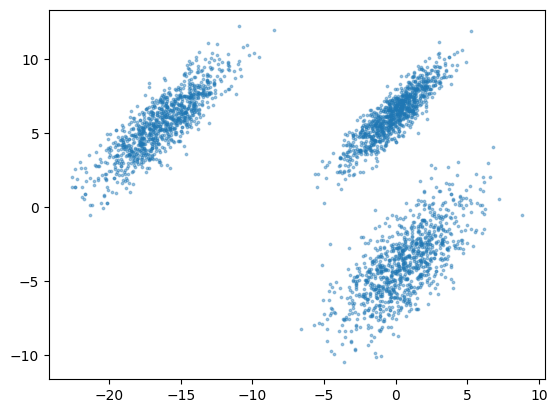

In [ ]:
# Generate random 2D data with 3 clusters
X = gen_data(k=3, dim=2, points_per_cluster=1000)

In [ ]:
# Create a Gaussian Mixture Model
gmm = GMM(3, 2)

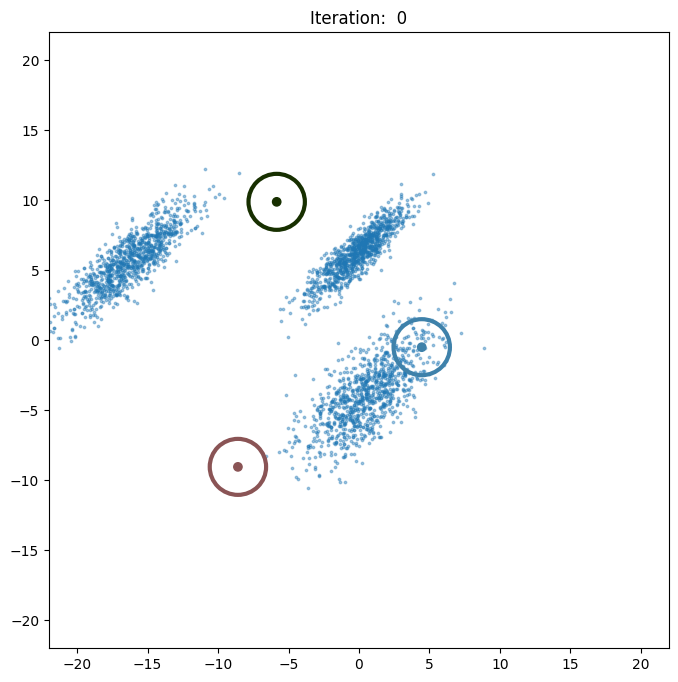

Iteration: 1, log-likelihood: -17663.8873


<Figure size 640x480 with 0 Axes>

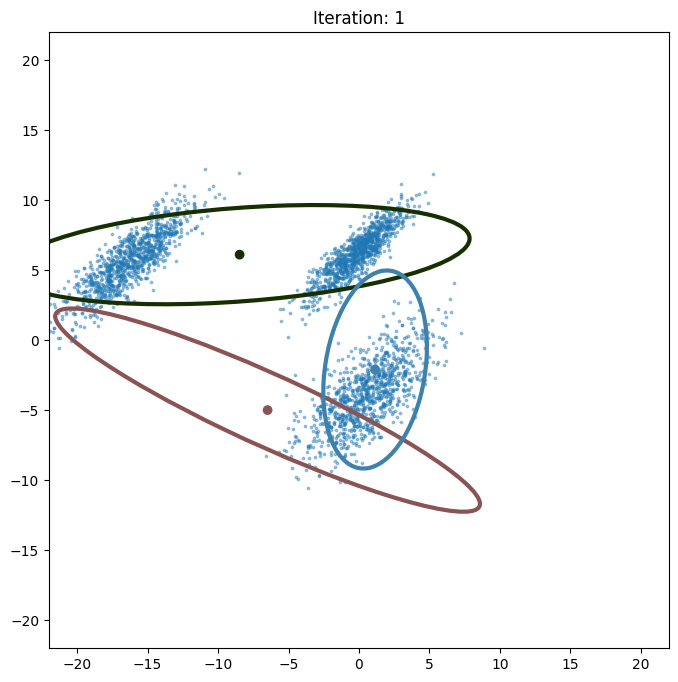

Iteration: 2, log-likelihood: -17491.0933


<Figure size 640x480 with 0 Axes>

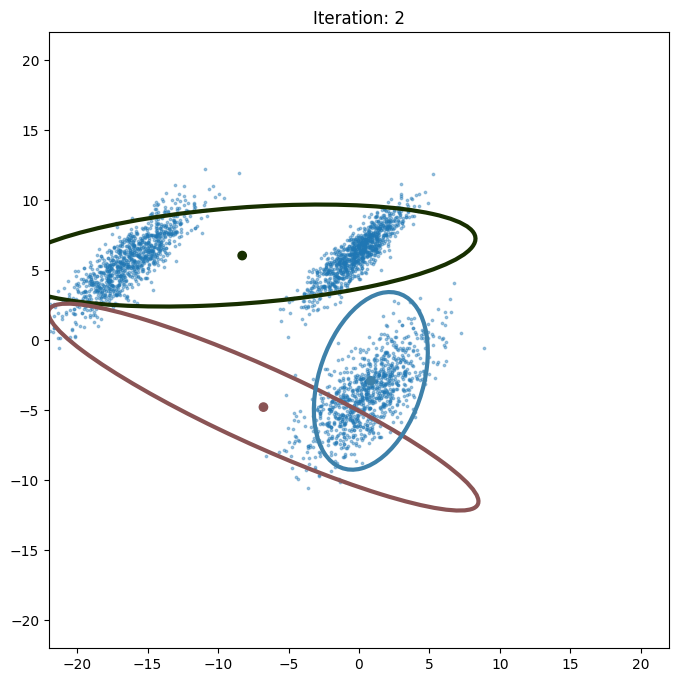

Iteration: 3, log-likelihood: -17254.1572


<Figure size 640x480 with 0 Axes>

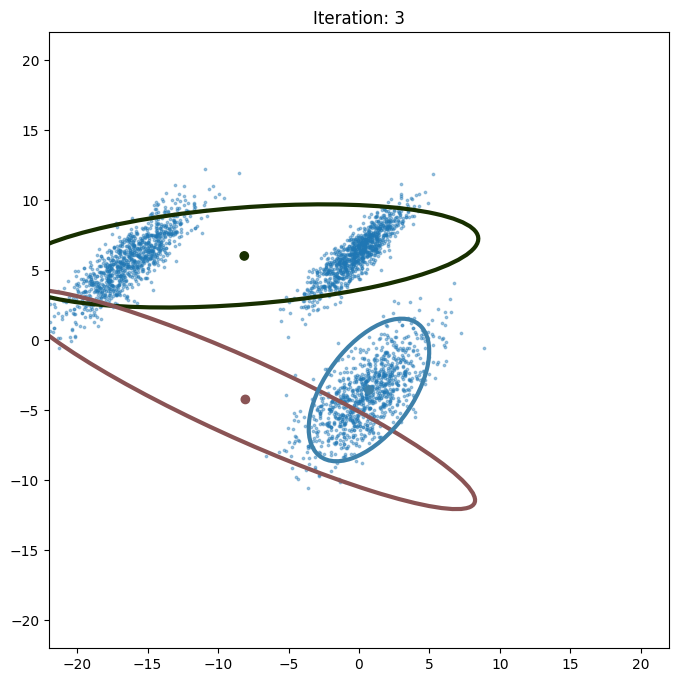

Iteration: 4, log-likelihood: -17171.1271


<Figure size 640x480 with 0 Axes>

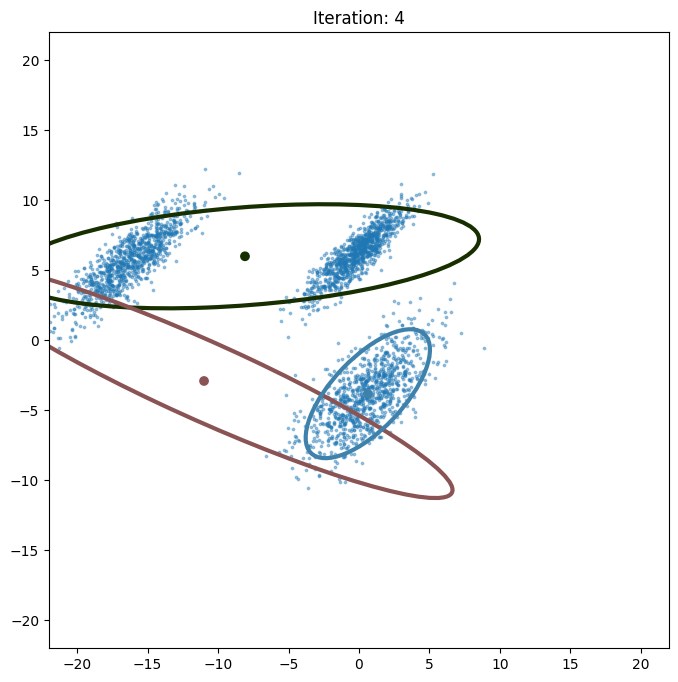

Iteration: 5, log-likelihood: -17162.3954


<Figure size 640x480 with 0 Axes>

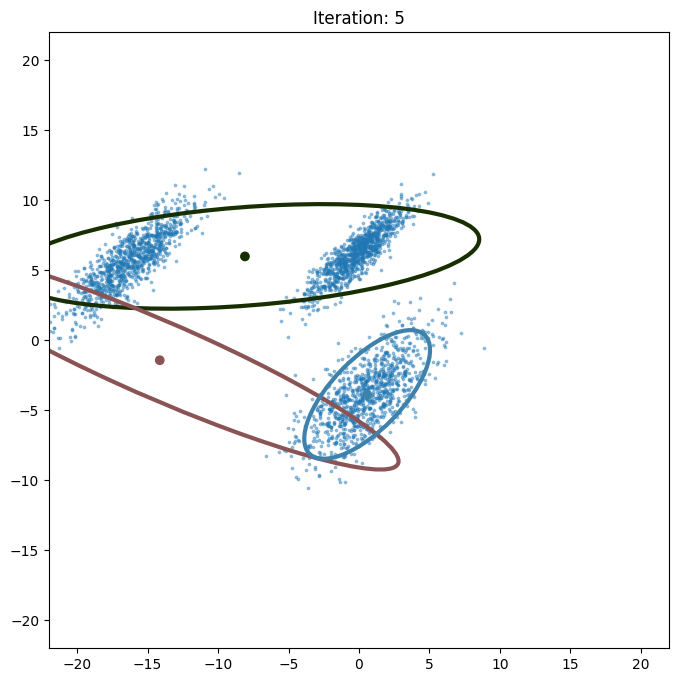

Iteration: 6, log-likelihood: -17157.8885


<Figure size 640x480 with 0 Axes>

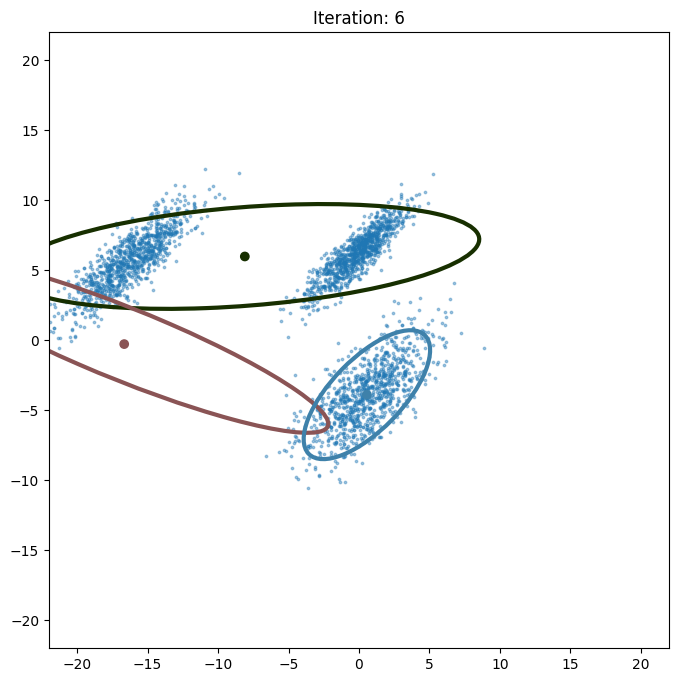

Iteration: 7, log-likelihood: -17152.0966


<Figure size 640x480 with 0 Axes>

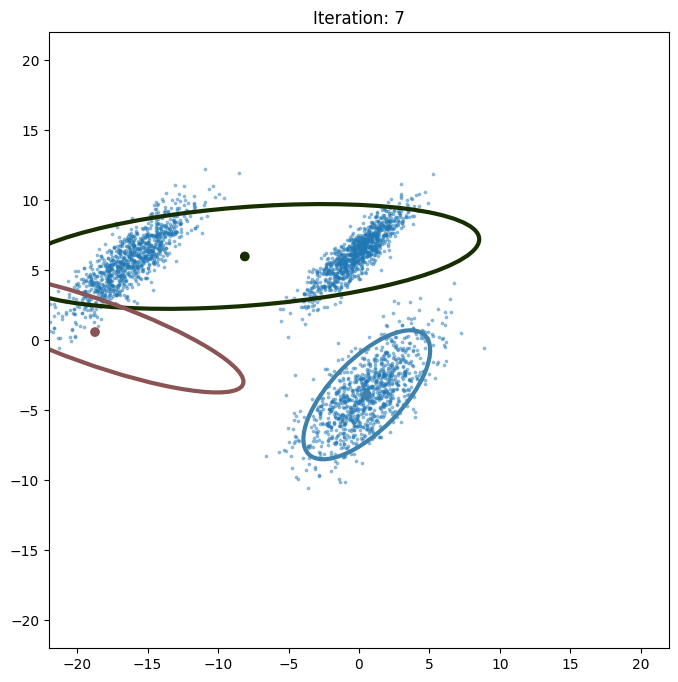

Iteration: 8, log-likelihood: -17131.2740


<Figure size 640x480 with 0 Axes>

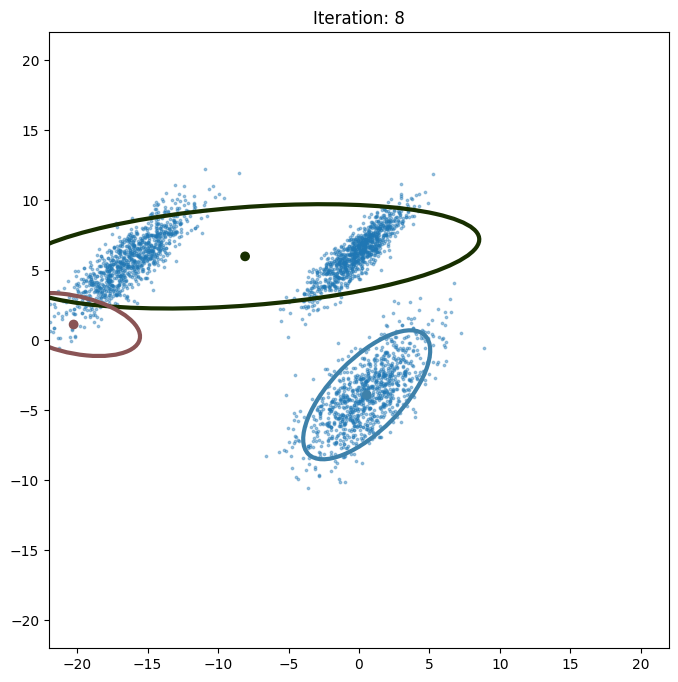

Iteration: 9, log-likelihood: -17099.6801


<Figure size 640x480 with 0 Axes>

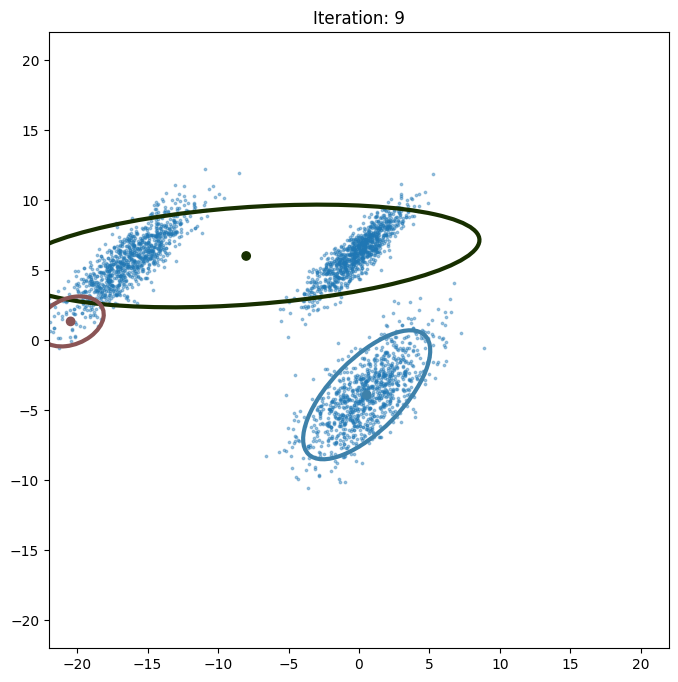

Iteration: 10, log-likelihood: -17074.6645


<Figure size 640x480 with 0 Axes>

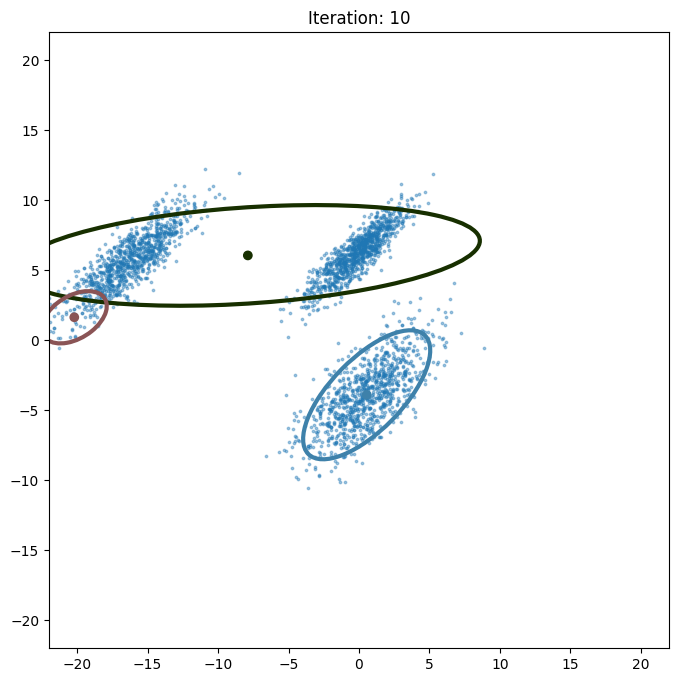

Iteration: 11, log-likelihood: -17034.6498


<Figure size 640x480 with 0 Axes>

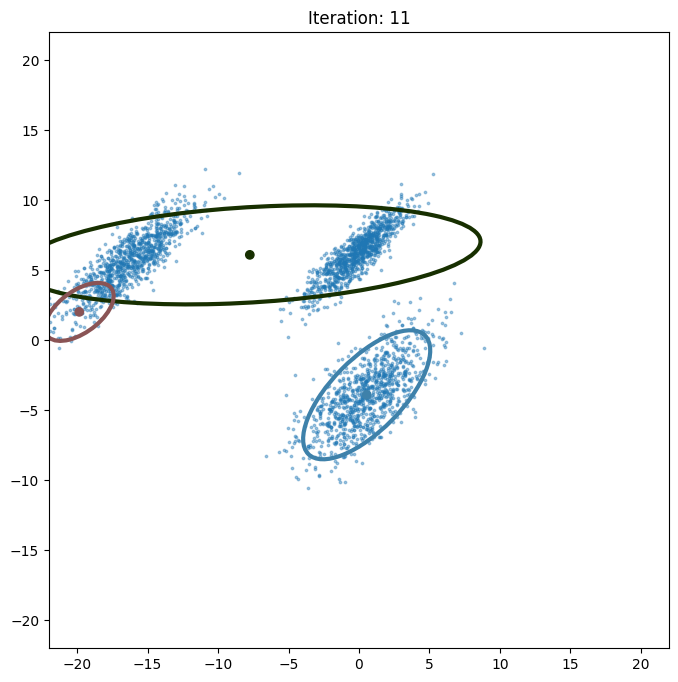

Iteration: 12, log-likelihood: -16962.6303


<Figure size 640x480 with 0 Axes>

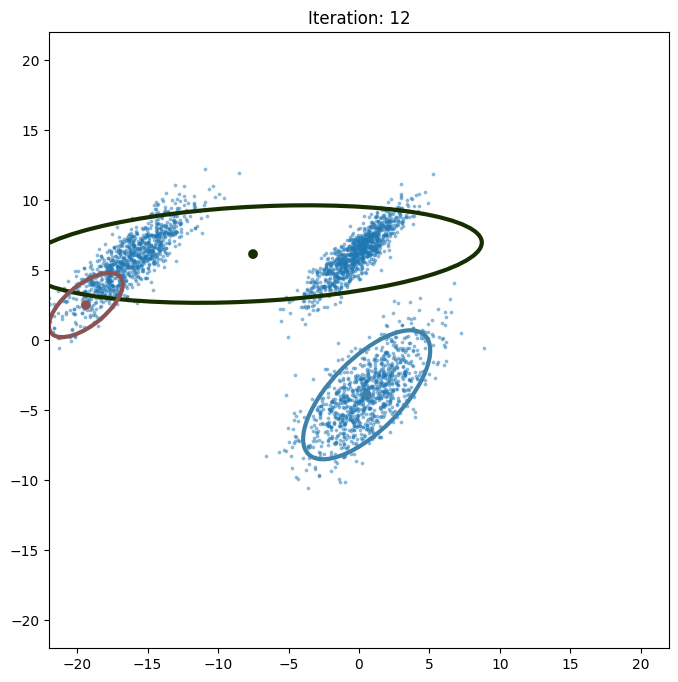

Iteration: 13, log-likelihood: -16853.4273


<Figure size 640x480 with 0 Axes>

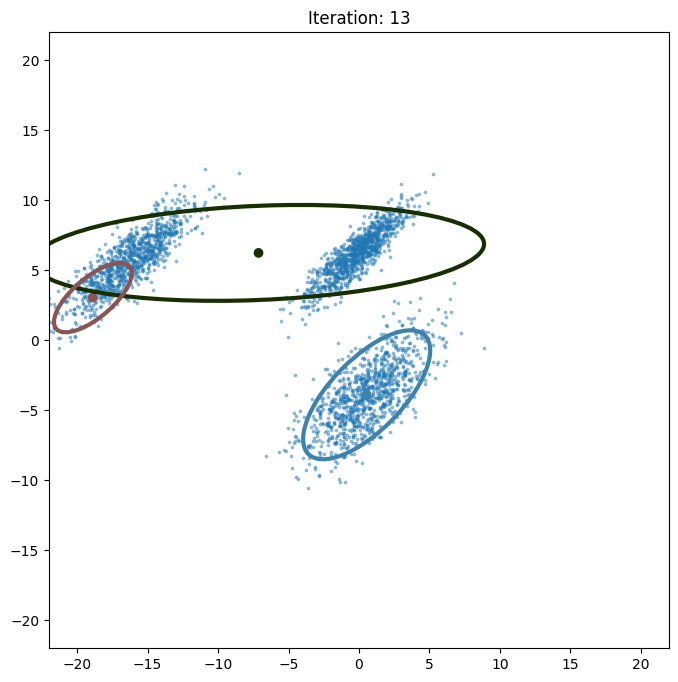

Iteration: 14, log-likelihood: -16711.4582


<Figure size 640x480 with 0 Axes>

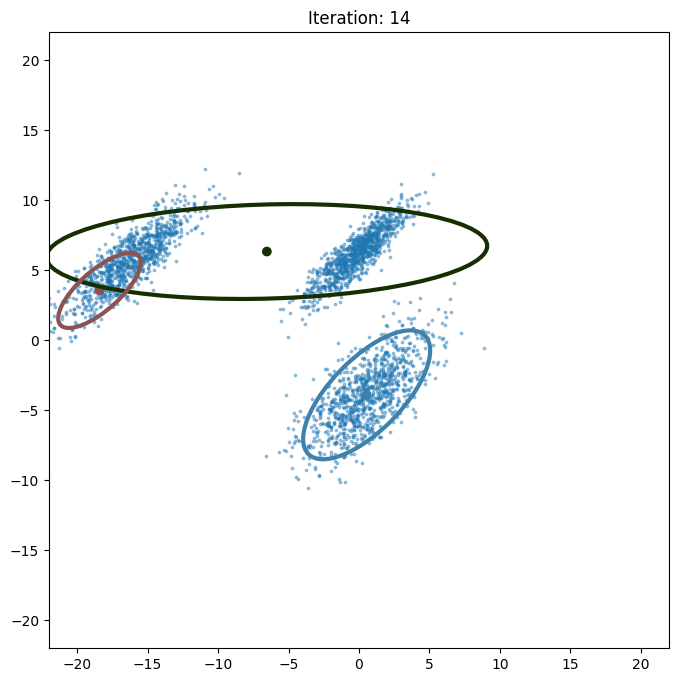

Iteration: 15, log-likelihood: -16536.6082


<Figure size 640x480 with 0 Axes>

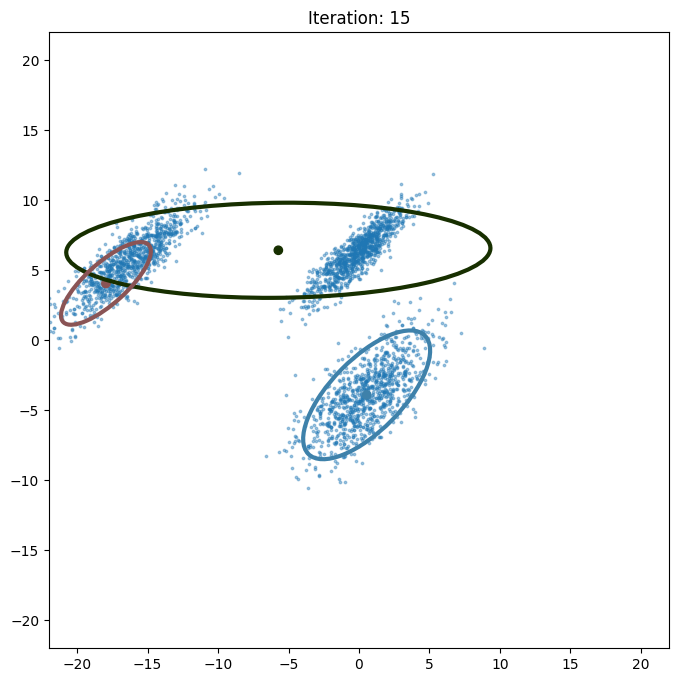

Iteration: 16, log-likelihood: -16326.5384


<Figure size 640x480 with 0 Axes>

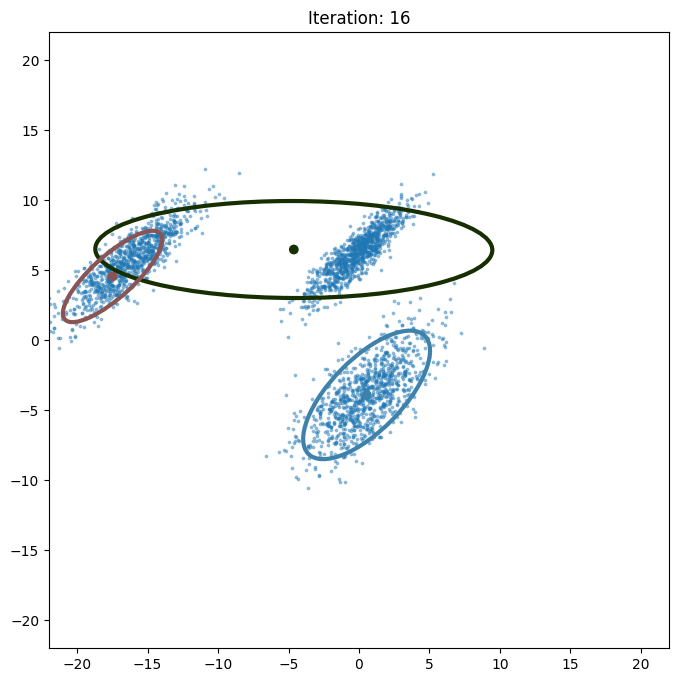

Iteration: 17, log-likelihood: -16084.6486


<Figure size 640x480 with 0 Axes>

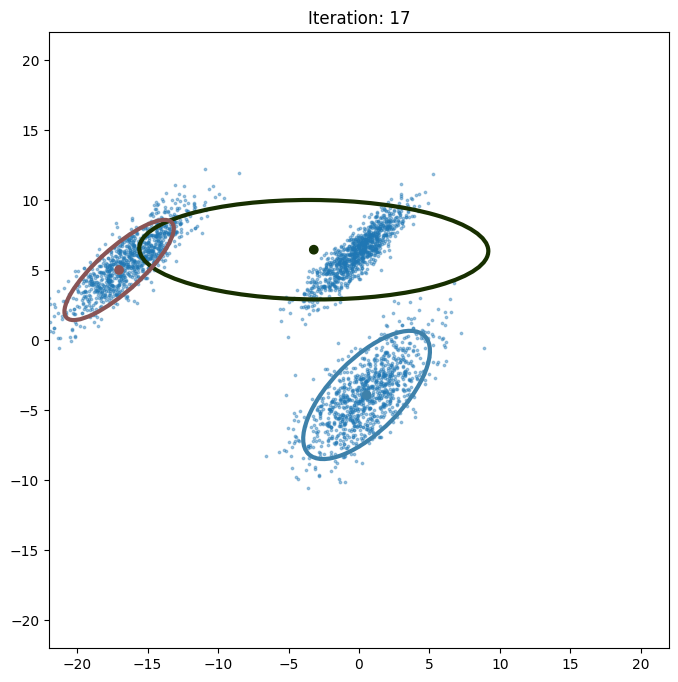

Iteration: 18, log-likelihood: -15745.1193


<Figure size 640x480 with 0 Axes>

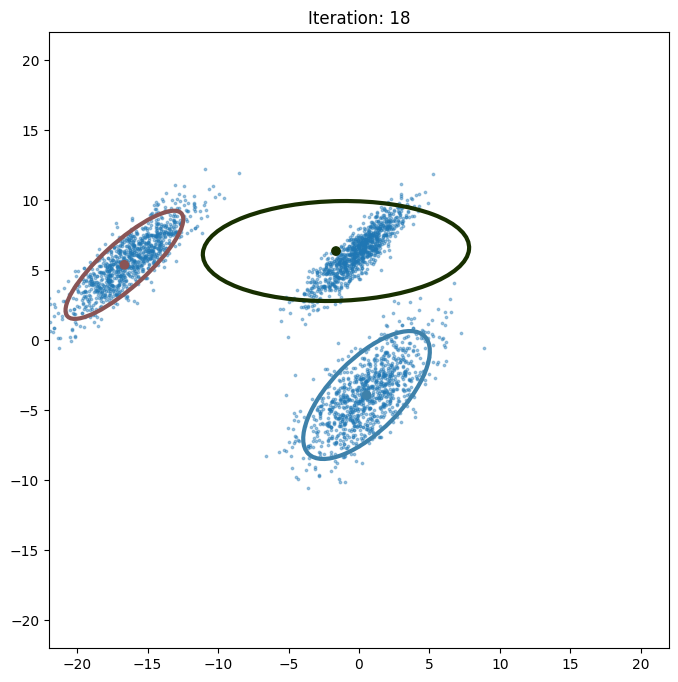

Iteration: 19, log-likelihood: -14976.0580


<Figure size 640x480 with 0 Axes>

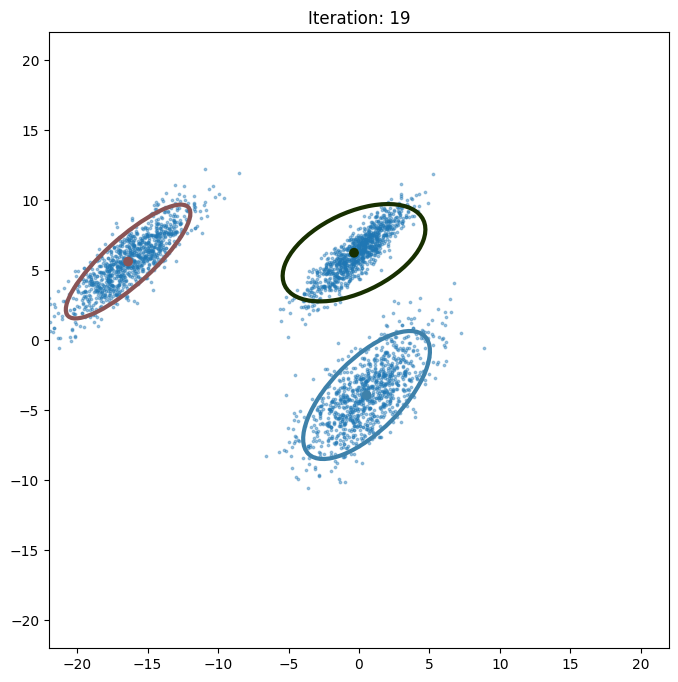

Iteration: 20, log-likelihood: -14401.1522


<Figure size 640x480 with 0 Axes>

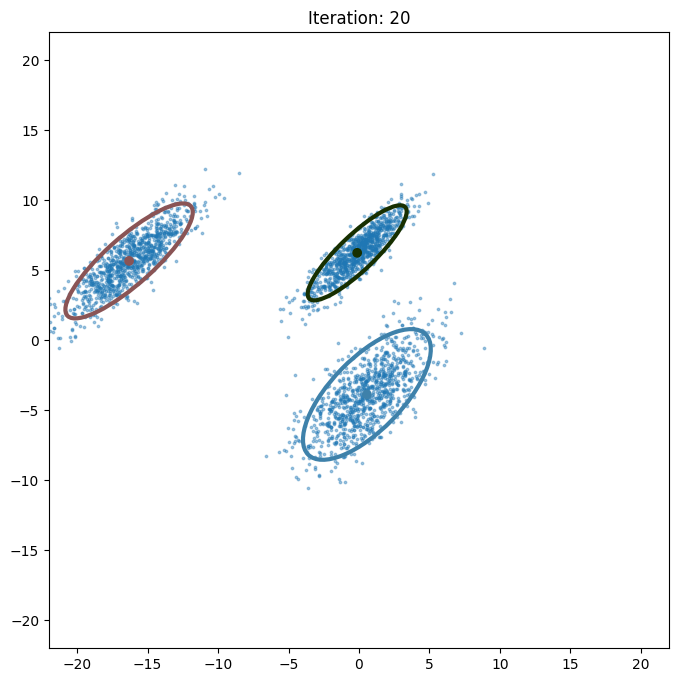

<Figure size 640x480 with 0 Axes>

In [ ]:
# Training the GMM using EM

# Initialize EM algo with data
gmm.init_em(X)

num_iters = 20
# Saving log-likelihood
log_likelihood = [gmm.log_likelihood(X)]
# plotting
plot("Iteration:  0")
for e in range(num_iters):
    # E-step
    gmm.e_step()
    # M-step
    gmm.m_step()
    # Computing log-likelihood
    log_likelihood.append(gmm.log_likelihood(X))
    print("Iteration: {}, log-likelihood: {:.4f}".format(e+1, log_likelihood[-1]))
    # plotting
    plot(title="Iteration: " + str(e+1))

### Bài tập tự thực hành 1: Sử dụng đoạn code trên để áp dựng cho dữ liệu là phần đầu vào của tập dữ liệu hoa Iris (bỏ trường tên loại hoa). Sau khi phân cụm xong hãy đối sánh kết quả với các phân loại đúng.

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# Load dữ liệu Iris
iris = datasets.load_iris()
X = iris.data  # Dữ liệu đầu vào
y_true = iris.target  # Nhãn thực tế

# Chuẩn hóa dữ liệu (tốt cho phân phối Gaussian)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Shape của dữ liệu Iris:", X_std.shape)


Shape của dữ liệu Iris: (150, 4)


 Lớp GMM_EM


In [3]:
from scipy.stats import multivariate_normal

class GMM_EM:
    def __init__(self, k, X, max_iter=100):
        self.k = k
        self.data = X
        self.num_points, self.dim = X.shape
        self.max_iter = max_iter

        # Khởi tạo ngẫu nhiên
        self.mu = np.random.randn(k, self.dim)
        self.sigma = np.array([np.eye(self.dim) for _ in range(k)])
        self.pi = np.ones(k) / k
        self.z = np.zeros((self.num_points, k))

    def e_step(self):
        for i in range(self.k):
            self.z[:, i] = self.pi[i] * multivariate_normal.pdf(self.data, mean=self.mu[i], cov=self.sigma[i])
        self.z /= self.z.sum(axis=1, keepdims=True)

    def m_step(self):
        sum_z = self.z.sum(axis=0)
        self.pi = sum_z / self.num_points
        self.mu = np.dot(self.z.T, self.data) / sum_z[:, np.newaxis]
        for i in range(self.k):
            diff = self.data - self.mu[i]
            self.sigma[i] = np.dot(self.z[:, i] * diff.T, diff) / sum_z[i]

    def fit(self):
        for _ in range(self.max_iter):
            self.e_step()
            self.m_step()

    def predict(self):
        return np.argmax(self.z, axis=1)

Huấn luyện mô hình và so sánh với nhãn thực tế

In [4]:
# Khởi tạo và huấn luyện
gmm = GMM_EM(k=3, X=X_std)
gmm.fit()

# Dự đoán nhãn
y_pred = gmm.predict()

# Chuyển đổi nhãn dự đoán cho phù hợp với nhãn thực
def convert_labels(y_pred, y_true):
    labels = np.zeros_like(y_pred)
    for i in range(3):
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask])[0]
    return labels

y_aligned = convert_labels(y_pred, y_true)

# Đánh giá độ chính xác
acc = accuracy_score(y_true, y_aligned)
print("Độ chính xác sau khi ánh xạ nhãn:", acc)


Độ chính xác sau khi ánh xạ nhãn: 0.74


**Trực quan hóa kết quả phân cụm**

Do dữ liệu Iris có 4 chiều nên chúng ta sẽ sử dụng PCA để giảm xuống 2 chiều rồi vẽ scatter plot để quan sát cách mô hình phân cụm.


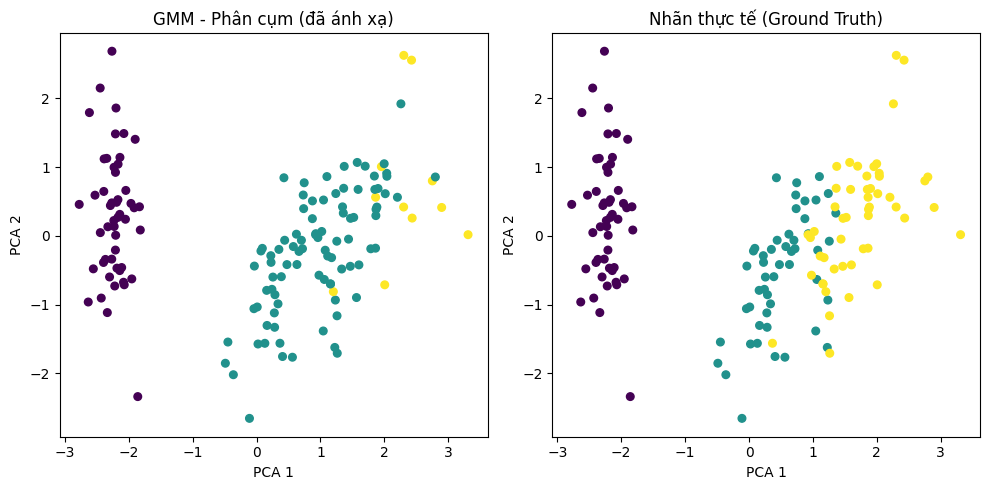

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Giảm số chiều để vẽ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Vẽ scatter plot theo nhãn dự đoán (sau ánh xạ)
plt.figure(figsize=(10, 5))

# Hình 1: Dự đoán từ mô hình GMM
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_aligned, cmap='viridis', s=30)
plt.title("GMM - Phân cụm (đã ánh xạ)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Hình 2: Nhãn thực tế
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=30)
plt.title("Nhãn thực tế (Ground Truth)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

### Bài tập tự thực hành 2: Hãy sử dụng thuật toán K-means để phân cụm dữ liệu tự tạo đã có trong ví dụ 1 của phần này. So sánh và giải thích kết quả.

Tạo dữ liệu 2D nhân tạo

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def gen_data(k=3, dim=2, points_per_cluster=200, lim=[-20, 20]):
    np.random.seed(42)
    x = []
    mean = np.random.rand(k, dim) * (lim[1] - lim[0]) + lim[0]
    for i in range(k):
        cov = np.random.rand(dim, dim+5)
        cov = np.matmul(cov, cov.T)
        _x = np.random.multivariate_normal(mean[i], cov, points_per_cluster)
        x += list(_x)
    x = np.array(x)
    return x

# Tạo dữ liệu
X_data = gen_data(k=3, dim=2, points_per_cluster=150)
print("Shape của dữ liệu:", X_data.shape)

Shape của dữ liệu: (450, 2)


Áp dụng thuật toán K-means để phân cụm
Sử dụng thư viện `sklearn.cluster.KMeans` để thực hiện thuật toán.

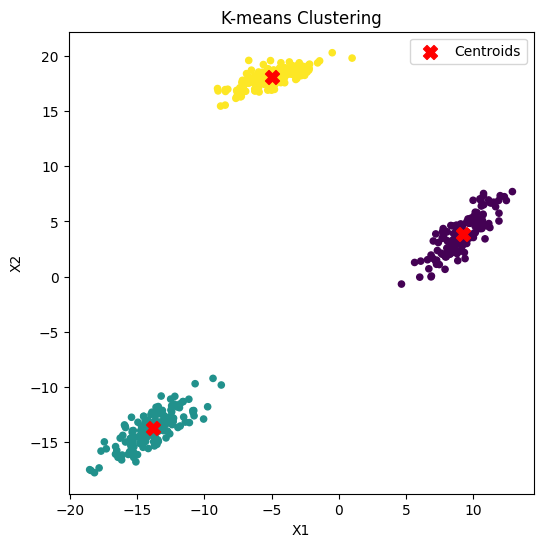

In [8]:
from sklearn.cluster import KMeans

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
y_kmeans = kmeans.fit_predict(X_data)

plt.figure(figsize=(6, 6))
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_kmeans, s=20, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='red', marker='X', label='Centroids')
plt.title("K-means Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

Phân cụm bằng Gaussian Mixture (sklearn)

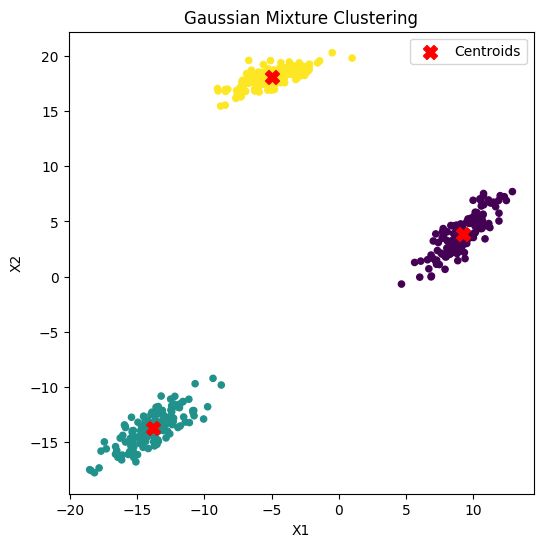

In [9]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0)
y_gmm = gmm.fit_predict(X_data)

plt.figure(figsize=(6, 6))
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_gmm, s=20, cmap='viridis')
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], s=100, c='red', marker='X', label='Centroids')
plt.title("Gaussian Mixture Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

 So sánh K-means và GMM bằng 2 chỉ số

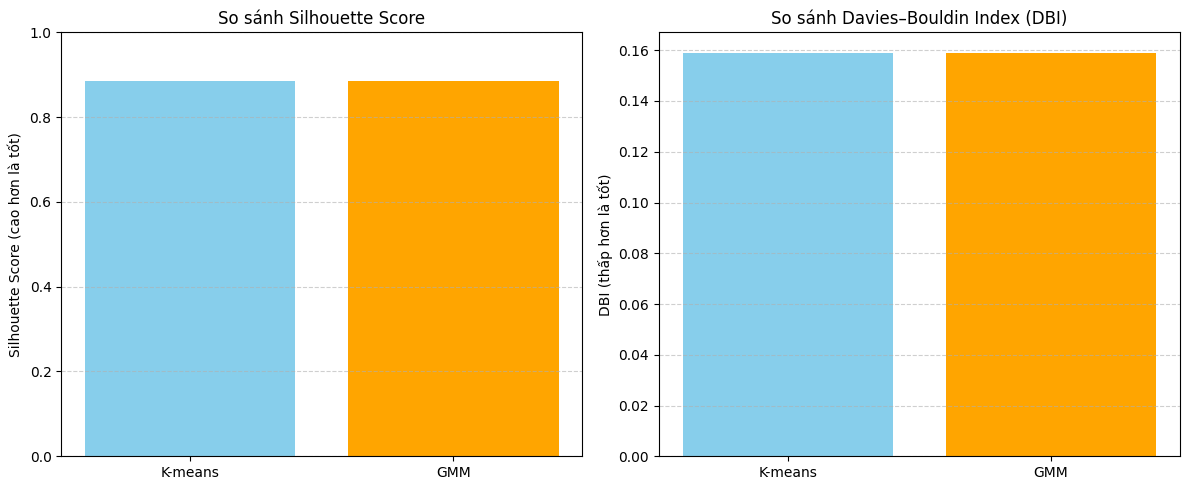

Silhouette Score - K-means: 0.886
Silhouette Score - GMM    : 0.886

Davies–Bouldin Index - K-means: 0.159
Davies–Bouldin Index - GMM    : 0.159


In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Tính các chỉ số đánh giá
sil_kmeans = silhouette_score(X_data, y_kmeans)
sil_gmm = silhouette_score(X_data, y_gmm)

dbi_kmeans = davies_bouldin_score(X_data, y_kmeans)
dbi_gmm = davies_bouldin_score(X_data, y_gmm)

# Trực quan hóa Silhouette Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['K-means', 'GMM'], [sil_kmeans, sil_gmm], color=['skyblue', 'orange'])
plt.title('So sánh Silhouette Score')
plt.ylabel('Silhouette Score (cao hơn là tốt)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Trực quan hóa DBI
plt.subplot(1, 2, 2)
plt.bar(['K-means', 'GMM'], [dbi_kmeans, dbi_gmm], color=['skyblue', 'orange'])
plt.title('So sánh Davies–Bouldin Index (DBI)')
plt.ylabel('DBI (thấp hơn là tốt)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# In giá trị ra màn hình
print(f"Silhouette Score - K-means: {sil_kmeans:.3f}")
print(f"Silhouette Score - GMM    : {sil_gmm:.3f}")
print()
print(f"Davies–Bouldin Index - K-means: {dbi_kmeans:.3f}")
print(f"Davies–Bouldin Index - GMM    : {dbi_gmm:.3f}")

## 2. Sử dụng thư viện sk-learn

## Ví dụ 2

EM: Silhouette Score = 0.5537, DBI = 0.5760


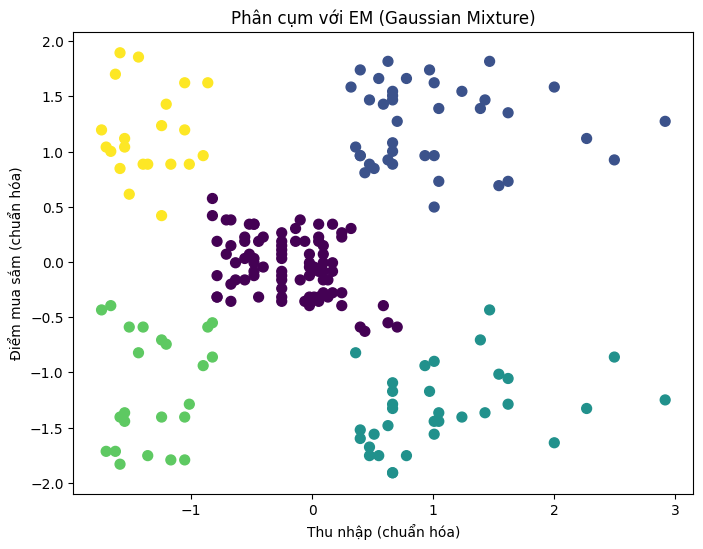

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Đọc dữ liệu
data = pd.read_csv('/content/drive/MyDrive/Classroom/MachineLearning/Lab11/shopping-data.csv', header=0, index_col=0)
X = data.iloc[:, 2:4].values  # Lấy cột thu nhập và điểm mua sắm

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Hàm vẽ kết quả phân cụm
def plot_clusters(X, labels, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel('Thu nhập (chuẩn hóa)')
    plt.ylabel('Điểm mua sắm (chuẩn hóa)')
    plt.show()

# 1. EM (Gaussian Mixture)
# Tìm số cụm tối ưu bằng BIC
lowest_bic = np.inf
bic = []
n_components_range = range(1, 7)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=0)
    gmm.fit(X_std)
    bic.append(gmm.bic(X_std))
    if bic[-1] < lowest_bic:
        lowest_bic = bic[-1]
        best_gmm = gmm

# Phân cụm với mô hình tốt nhất
em_labels = best_gmm.predict(X_std)
em_silhouette = silhouette_score(X_std, em_labels)
em_dbi = davies_bouldin_score(X_std, em_labels)
print(f"EM: Silhouette Score = {em_silhouette:.4f}, DBI = {em_dbi:.4f}")
plot_clusters(X_std, em_labels, 'Phân cụm với EM (Gaussian Mixture)')

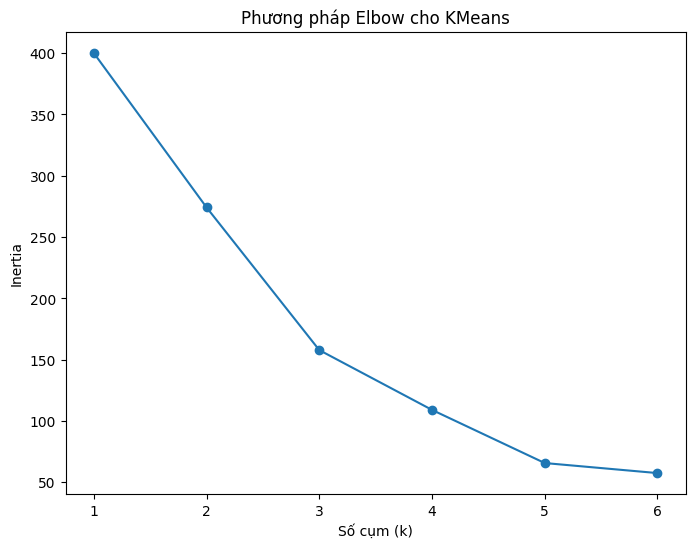

KMeans: Silhouette Score = 0.5547, DBI = 0.5722


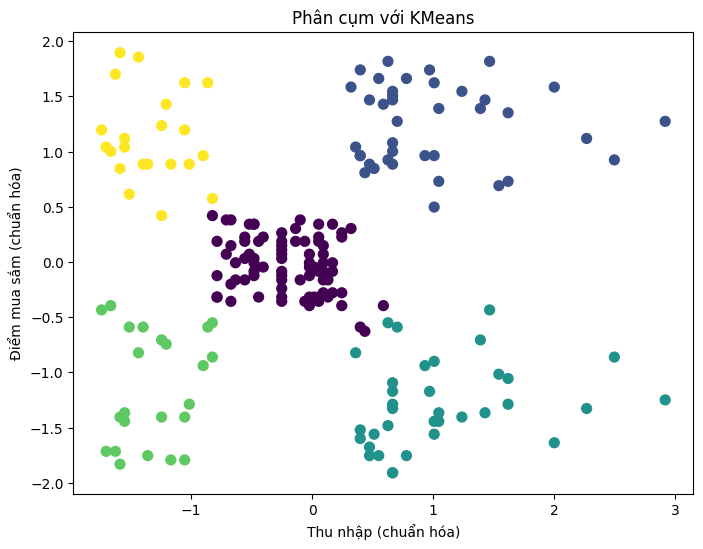

In [ ]:

# 2. KMeans
# Tìm số cụm tối ưu bằng phương pháp Elbow
inertias = []
k_range = range(1, 7)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_std)
    inertias.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o')
plt.title('Phương pháp Elbow cho KMeans')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.show()

# Chọn k = 5 (dựa trên biểu đồ Elbow hoặc kinh nghiệm)
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X_std)
kmeans_labels = kmeans.labels_
kmeans_silhouette = silhouette_score(X_std, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X_std, kmeans_labels)
print(f"KMeans: Silhouette Score = {kmeans_silhouette:.4f}, DBI = {kmeans_dbi:.4f}")
plot_clusters(X_std, kmeans_labels, 'Phân cụm với KMeans')

DBScan: Silhouette Score = 0.3504, DBI = 0.8285


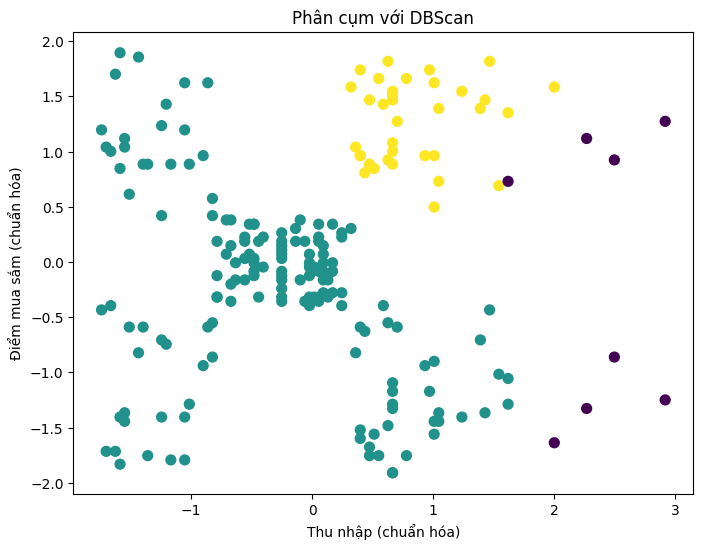

In [ ]:
# 3. DBScan
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_std)
# Kiểm tra xem DBScan có tạo cụm hợp lệ không
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_std, dbscan_labels)
    dbscan_dbi = davies_bouldin_score(X_std, dbscan_labels)
    print(f"DBScan: Silhouette Score = {dbscan_silhouette:.4f}, DBI = {dbscan_dbi:.4f}")
else:
    print("DBScan: Không tạo được cụm hợp lệ với tham số hiện tại")
plot_clusters(X_std, dbscan_labels, 'Phân cụm với DBScan')

In [ ]:
# So sánh kết quả
print("\nSo sánh chất lượng phân cụm:")
print(f"EM: Silhouette = {em_silhouette:.4f}, DBI = {em_dbi:.4f}")
print(f"KMeans: Silhouette = {kmeans_silhouette:.4f}, DBI = {kmeans_dbi:.4f}")
if len(set(dbscan_labels)) > 1:
    print(f"DBScan: Silhouette = {dbscan_silhouette:.4f}, DBI = {dbscan_dbi:.4f}")
else:
    print("DBScan: Không thể đánh giá do không tạo cụm hợp lệ")


So sánh chất lượng phân cụm:
EM: Silhouette = 0.5537, DBI = 0.5760
KMeans: Silhouette = 0.5547, DBI = 0.5722
DBScan: Silhouette = 0.3504, DBI = 0.8285

So sánh chất lượng phân cụm:
EM: Silhouette = 0.5537, DBI = 0.5760
KMeans: Silhouette = 0.5547, DBI = 0.5722
DBScan: Silhouette = 0.3504, DBI = 0.8285


## 2.3.Ví dụ mở rộng

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu từ Google Drive
file_path = "/content/drive/MyDrive/Classroom/MachineLearning/Lab10/Sales_Transactions_Dataset_Weekly.csv"
df = pd.read_csv(file_path)

# Hiển thị kích thước và tên cột
print("Kích thước dữ liệu:", df.shape)
print("Các cột:", df.columns.tolist())

# Giữ lại 52 cột dữ liệu theo tuần (tuần 0 đến tuần 51)
X = df.iloc[:, 1:53].values  # bỏ cột đầu là ID sản phẩm

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Shape dữ liệu chuẩn hóa:", X_std.shape)


Kích thước dữ liệu: (811, 107)
Các cột: ['Product_Code', 'W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'W19', 'W20', 'W21', 'W22', 'W23', 'W24', 'W25', 'W26', 'W27', 'W28', 'W29', 'W30', 'W31', 'W32', 'W33', 'W34', 'W35', 'W36', 'W37', 'W38', 'W39', 'W40', 'W41', 'W42', 'W43', 'W44', 'W45', 'W46', 'W47', 'W48', 'W49', 'W50', 'W51', 'MIN', 'MAX', 'Normalized 0', 'Normalized 1', 'Normalized 2', 'Normalized 3', 'Normalized 4', 'Normalized 5', 'Normalized 6', 'Normalized 7', 'Normalized 8', 'Normalized 9', 'Normalized 10', 'Normalized 11', 'Normalized 12', 'Normalized 13', 'Normalized 14', 'Normalized 15', 'Normalized 16', 'Normalized 17', 'Normalized 18', 'Normalized 19', 'Normalized 20', 'Normalized 21', 'Normalized 22', 'Normalized 23', 'Normalized 24', 'Normalized 25', 'Normalized 26', 'Normalized 27', 'Normalized 28', 'Normalized 29', 'Normalized 30', 'Normalized 31', 'Normalized 32', 'Normalized 33', 'Normal

Tìm số cụm tối ưu bằng tiêu chí BIC

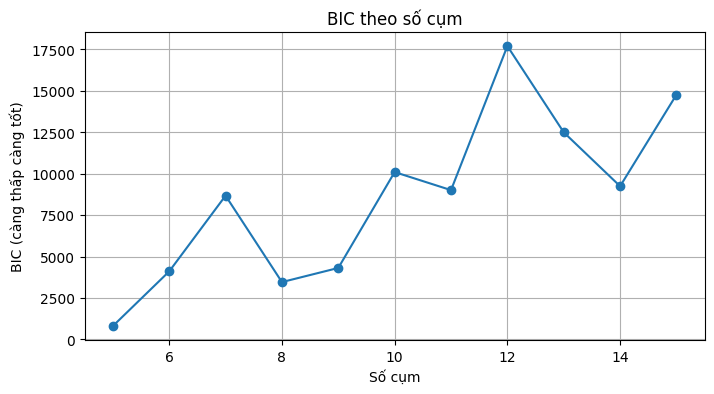

Số cụm tối ưu theo BIC: 5


In [15]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

n_range = range(5, 16)
bic_scores = []

for k in n_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(X_std)
    bic_scores.append(gmm.bic(X_std))

# Vẽ BIC
plt.figure(figsize=(8, 4))
plt.plot(n_range, bic_scores, marker='o')
plt.title("BIC theo số cụm")
plt.xlabel("Số cụm")
plt.ylabel("BIC (càng thấp càng tốt)")
plt.grid(True)
plt.show()

# Lấy số cụm tốt nhất
best_k = n_range[np.argmin(bic_scores)]
print("Số cụm tối ưu theo BIC:", best_k)


Huấn luyện GMM với số cụm tối ưu và phân cụm sản phẩm

In [16]:
# Huấn luyện mô hình tốt nhất
best_gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0)
labels = best_gmm.fit_predict(X_std)

# Thêm nhãn vào DataFrame để tiện xem
df['Cluster'] = labels
df.head()


,Product_Code,W0,W1,W2,W3,W4,W5,W6,W7,W8,...,Normalized 43,Normalized 44,Normalized 45,Normalized 46,Normalized 47,Normalized 48,Normalized 49,Normalized 50,Normalized 51,Cluster
0,P1,11,12,10,8,13,12,14,21,6,...,0.22,0.28,0.39,0.50,0.00,0.22,0.17,0.11,0.39,2
1,P2,7,6,3,2,7,1,6,3,3,...,0.40,0.50,0.10,0.10,0.40,0.50,0.10,0.60,0.00,2
2,P3,7,11,8,9,10,8,7,13,12,...,1.00,0.18,0.18,0.36,0.45,1.00,0.45,0.45,0.36,2
3,P4,12,8,13,5,9,6,9,13,13,...,0.47,0.06,0.12,0.24,0.35,0.71,0.35,0.29,0.35,2
4,P5,8,5,13,11,6,7,9,14,9,...,0.53,0.27,0.60,0.20,0.20,0.13,0.53,0.33,0.40,2


Trực quan hóa kết quả phân cụm bằng PCA

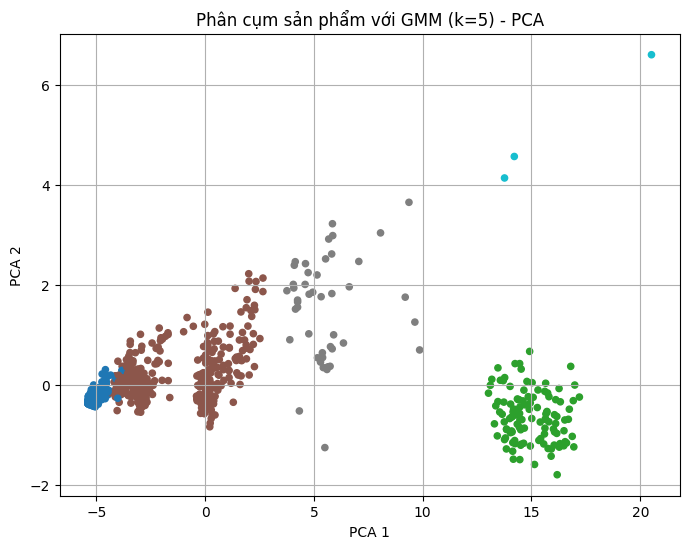

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=20)
plt.title(f'Phân cụm sản phẩm với GMM (k={best_k}) - PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()
